In [26]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [27]:
# 현재 데이터들
# 1️⃣	customers.csv	customer_id, name, region	                    고객 정보
# 2️⃣	orders.csv	    order_id, customer_id, product_id, order_date	주문 기본 정보
# 3️⃣	payments.csv	payment_id, order_id, amount	                결제 금액 연결
# 4️⃣	products.csv	product_id, category, price	                    상품 및 카테고리
# 5️⃣	shipping.csv	order_id, ship_date, status	                    배송 현황 (선택적 참고)

In [28]:
# 문제 1: 카테고리별 월별 매출액 추이를 분석하고, 가장 성장률이 높은 카테고리를 식별하세요.
# 시각화: 라인 플롯

# 비즈니스 목적: 시간에 따른 카테고리별 성과를 파악하여 어떤 카테고리에 집중해야 할지 결정합니다.

In [29]:
# 1. 기본 라이브러리 불러오기
# import pandas as pd                 # 데이터 분석 라이브러리
# import matplotlib.pyplot as plt     # 그래프 시각화 라이브러리
# import seaborn as sns               # 시각화 고급화 (motplolib 기반)
# import numpy as np                  # 수치 계산 및 배열 연산을 위한 라이브러리

카테고리별 평균 월별 성장률:
  category  growth_rate
6      화장품     1.815521
4       의류     1.133059
2    스포츠용품     0.971449
0       가구     0.772108
3       식품     0.495673
1       도서     0.405621
5     전자제품     0.379029


C:\Users\TJ\AppData\Local\Temp\ipykernel_7552\4258813275.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['total_sales'].iloc[-1] - x['total_sales'].iloc[0]) / x['total_sales'].iloc[0])


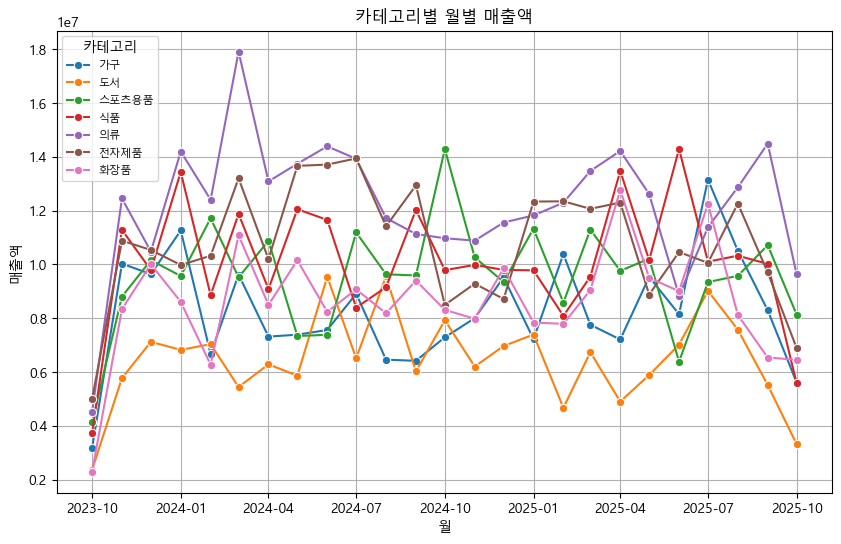

In [30]:
# ✅ 1. 날짜에서 '월' 단위로 그룹화하기 위해 'order_date'를 월 단위로 변환
df['order_month'] = df['order_date'].dt.to_period('M')  # '2024-03' 형태로 변환
df['order_month'] = df['order_month'].dt.to_timestamp()  # 다시 Timestamp 형태로 변환

# ✅ 2. 월별·카테고리별 매출액 계산
# 'total_sales'는 이미 quantity * price 로 계산된 상태라고 가정
monthly_sales = df.groupby(['order_month', 'category'])['total_sales'].sum().reset_index()

# ✅ 4. 카테고리별 성장률 계산
# 각 카테고리별로 첫 달 대비 마지막 달 성장률을 계산
growth_rate = (
    monthly_sales.groupby('category')
    .apply(lambda x: (x['total_sales'].iloc[-1] - x['total_sales'].iloc[0]) / x['total_sales'].iloc[0])
    .reset_index(name='growth_rate')
)

# ✅ 5. 성장률 순위 정렬
growth_rate = growth_rate.sort_values(by='growth_rate', ascending=False)

# ✅ 6. 성장률 출력
print("카테고리별 평균 월별 성장률:")
print(growth_rate)



# ✅ 3. 시각화 (카테고리별 월별 매출 추이)
plt.figure(figsize=(10, 6)) # 도화지 크기
sns.lineplot(data=monthly_sales, x='order_month', y='total_sales', hue='category', marker='o') # 선 그래프,x축 월별 주문 시점, y축 해당 월의 총 매출, 마커 매출 지점 동그라미 표시
plt.title('카테고리별 월별 매출액', fontsize=12) # 메인 타이틀 제목 , 글씨 크기
plt.xlabel('월') # x측 제목
plt.ylabel('매출액') # y측 제목
plt.legend(title='카테고리', loc='upper left', fontsize=8) # 범례 제목, 위치, 글씨  크기    
plt.grid(True) # 격자선 표시
plt.show() # 그래프 화면 출력





In [31]:
# 문제 2: 고객별 재주문까지 걸리는 평균 시간을 분석하고, 가장 재구매 주기가 짧은 충성 고객 TOP 5를 찾으세요.
# 시각화: 바 차트

# 비즈니스 목적: 고객의 재구매 주기를 파악하여, 주기에 맞춘 리마인드 알림이나 프로모션을 통해 고객의 이탈을 방지하고 재구매를 유도합니다.

# 출력 결과를 보고 코딩하세요



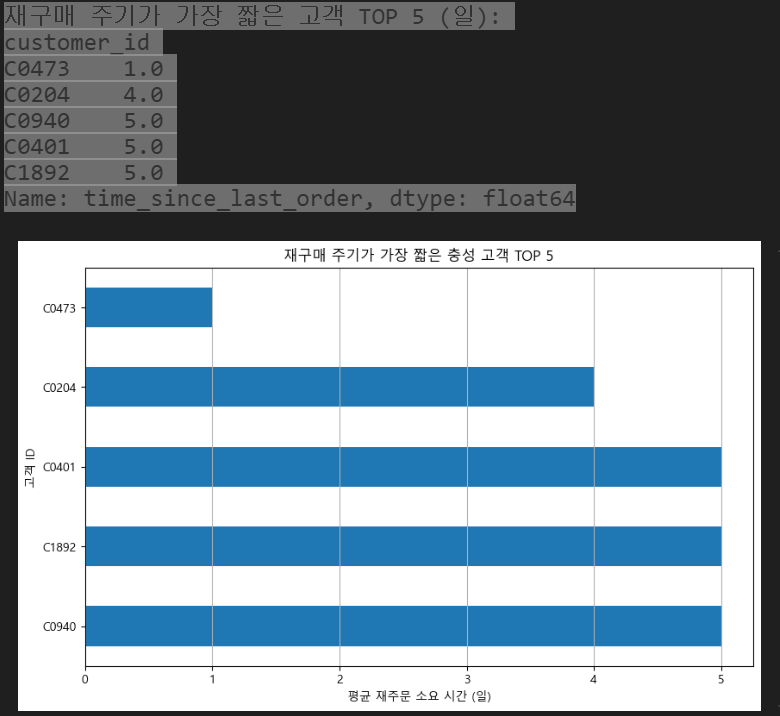



In [32]:
# # 고객별 주문 날짜 정렬
# df = df.sort_values(['customer_id','order_date']) # df에서 고객 아이디와, 주문 목록 가져오기

# df.groupby('category')['monthly_growth_rate'].mean()

재구매 주기가 가장 짧은 고객 TOP 5 (일):
customer_id
C0473    1.0
C0204    4.0
C0940    5.0
C0401    5.0
C1892    5.0
Name: time_since_last_order, dtype: float64


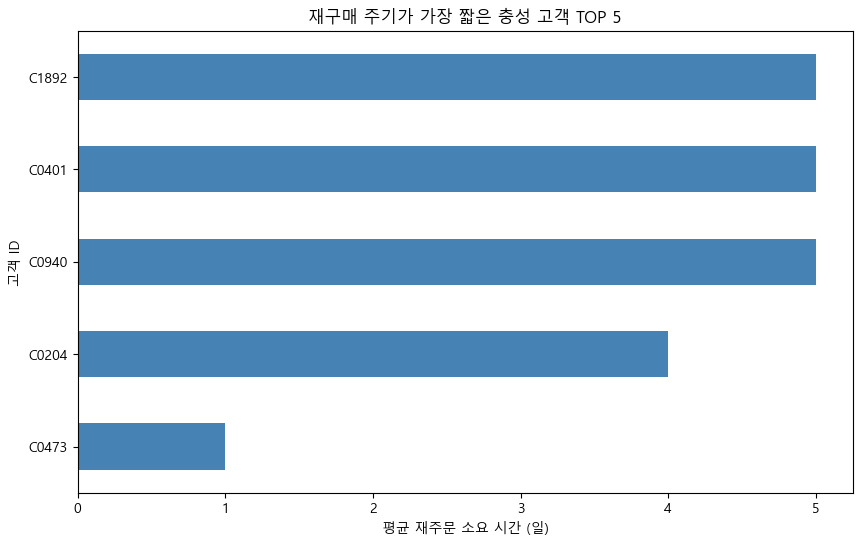

In [33]:
# ==========================
# 문제 2. 고객별 재주문 주기 분석
# ==========================

# 1️⃣ 고객별로 주문일 기준으로 정렬
# - diff() 함수는 '바로 이전 행'과의 차이를 계산하므로
#   고객별 주문 날짜가 순서대로 정렬되어 있어야 정확히 작동함
df = df.sort_values(['customer_id', 'order_date'])

# 2️⃣ 고객별 주문 간격(일 단위) 계산
# - groupby('customer_id'): 고객별로 묶어서
# - ['order_date'].diff(): 각 고객의 주문일 차이를 계산
# - .dt.days: 날짜 차이를 '일수(int)'로 변환
df['time_since_last_order'] = df.groupby('customer_id')['order_date'].diff().dt.days

# 3️⃣ 고객별 평균 재주문 소요 시간 계산
# - 각 고객이 주문한 여러 간격 중 평균값을 구함
# - 첫 주문은 diff() 결과가 NaN이므로 dropna()로 제외
avg_reorder = (
    df.groupby('customer_id')['time_since_last_order']
    .mean()
    .dropna()
)

# 4️⃣ 평균 재주문 시간이 가장 짧은 고객 TOP 5 추출
# - sort_values(): 오름차순 정렬 (짧은 주기가 먼저)
# - head(5): 상위 5명 선택
top5 = avg_reorder.sort_values().head(5)

# 5️⃣ 결과 출력 (Series 형태로 보여줌)
print("재구매 주기가 가장 짧은 고객 TOP 5 (일):")
print(top5)

# 6️⃣ 시각화 - 가로형 막대 그래프(barh)
# - kind='barh': 가로 방향 막대그래프
# - color='steelblue': 보기 좋은 파란색 계열로 표시
# - figsize: 그래프 크기 설정
plt.figure(figsize=(10, 6))
top5.sort_values().plot(kind='barh', color='steelblue')

# 7️⃣ 그래프 제목 및 축 레이블 설정
plt.title('재구매 주기가 가장 짧은 충성 고객 TOP 5')  # 그래프 제목
plt.xlabel('평균 재주문 소요 시간 (일)')             # X축 라벨
plt.ylabel('고객 ID')                               # Y축 라벨

# 8️⃣ 그래프 출력
plt.show()


재구매 주기가 가장 짧은 고객 TOP 5 (일):
customer_id
C0473    1.0
C0204    4.0
C0940    5.0
C0401    5.0
C1892    5.0
Name: time_since_last_order, dtype: float64


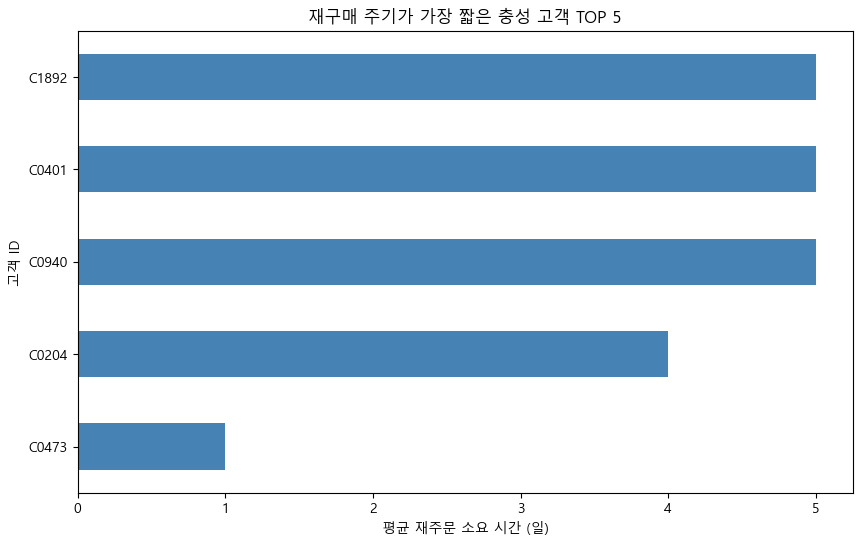

In [34]:
# ==========================
# 문제 2. 고객별 재주문 주기 분석
# ==========================

# 1️⃣ 고객별로 주문일을 오름차순 정렬
#    이유: diff()는 '이전 행'과 비교하므로, 순서가 뒤죽이면 계산이 틀림
df = df.sort_values(['customer_id', 'order_date'])

# 2️⃣ 고객별 주문일 사이의 일(day) 차이 계산
#    groupby('customer_id'): 고객별로 묶음 (고객 단위 계산을 위해)
#    ['order_date'].diff(): 같은 고객 내에서 이전 주문일과의 차이 계산
#    .dt.days: 날짜 차이(Timedelta)를 '일수'로 변환
df['time_since_last_order'] = df.groupby('customer_id')['order_date'].diff().dt.days

# 3️⃣ 고객별 평균 재주문 간격 계산
#    groupby('customer_id'): 고객별로 묶어서
#    ['time_since_last_order'].mean(): 평균값 계산
#    dropna(): 첫 주문은 diff()가 없으므로 NaN → 제거
#    결과는 'Series' 형태로 반환됨
#    └─ index → customer_id (고객 ID)
#    └─ value → 평균 재주문 일수
avg_reorder = (
    df.groupby('customer_id')['time_since_last_order']
    .mean()
    .dropna()
)

# 4️⃣ 평균 재주문 간격이 가장 짧은 고객 TOP 5 선택
#    avg_reorder는 이미 'Series' 형태이므로
#    (index가 customer_id, 값이 평균 재주문 일수)
#    여기서는 mean()이 아니라 sort_values()만 사용
#    sort_values(): 값을 기준으로 오름차순 정렬 (짧은 주기 → 충성 고객)
#    head(5): 상위 5명 추출
top5 = avg_reorder.sort_values().head(5)

# 5️⃣ 결과 출력
#    Series이므로 print()하면 아래처럼 나옴:
#    index = customer_id, value = 평균 재주문 일수
print("재구매 주기가 가장 짧은 고객 TOP 5 (일):")
print(top5)

# 6️⃣ 시각화 (Series 그대로 사용)
#    Series.plot()은 자동으로 index를 x축(label), value를 y값으로 사용
#    kind='barh': 가로 방향 막대그래프
#    color='steelblue': 막대 색상
#    figsize=(10, 6): 그래프 크기 설정
plt.figure(figsize=(10, 6))
top5.plot(kind='barh', color='steelblue')

# 7️⃣ 그래프 제목 및 축 라벨 설정
plt.title('재구매 주기가 가장 짧은 충성 고객 TOP 5')  # 그래프 제목
plt.xlabel('평균 재주문 소요 시간 (일)')             # X축 라벨 (value)
plt.ylabel('고객 ID')                               # Y축 라벨 (index)

# 8️⃣ 그래프 출력
plt.show()


In [35]:
# 문제 3: 재구매율이 가장 높은 상위 10개 상품을 찾으세요.
# 비즈니스 목적: 고객 충성도가 높은 상품을 파악하고, 해당 상품의 재고를 안정적으로 관리하거나 충성 고객 대상 마케팅에 활용합니다.

# 출력 결과를 보고 코딩하세요




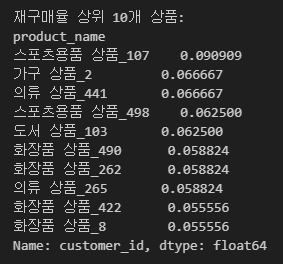


In [36]:
# ==========================
# 문제 3. 재구매율이 가장 높은 상위 10개 상품
# ==========================

# 1️⃣ 고객별로 상품 주문 횟수를 계산
#    groupby(['product_id', 'customer_id']): 
#       - 상품(product_id)과 고객(customer_id) 기준으로 묶음
#    ['order_id'].nunique(): 
#       - 각 고객이 해당 상품을 몇 번 주문했는지 계산 (중복 주문 제거)
product_customer_counts = (
    df.groupby(['product_id', 'customer_id'])['order_id']
    .nunique()
    .reset_index(name='order_count')
)
# 📘 결과 예시:
# product_id | customer_id | order_count
# --------------------------------------
# P001       | C001        | 2
# P001       | C002        | 1
# P002       | C001        | 3
# ...

# 2️⃣ 상품별 재구매 고객 수와 전체 고객 수 계산
#    (1) 재구매 고객 수 = order_count >= 2 인 고객 수
#    (2) 전체 고객 수 = 해당 상품을 한 번이라도 산 고객 수
reorder_summary = (
    product_customer_counts.groupby('product_id')
    .apply(lambda x: (x['order_count'] >= 2).sum() / x['customer_id'].nunique())
    .reset_index(name='repurchase_rate')  # 재구매율 컬럼 이름 지정
)
# 📘 결과 예시:
# product_id | repurchase_rate
# -----------------------------
# P001       | 0.25
# P002       | 0.10
# ...

# 3️⃣ product_id 기준으로 product_name과 병합 (이름 표시용)
reorder_summary = pd.merge(reorder_summary, products_df[['product_id', 'product_name']], on='product_id', how='left')

# 4️⃣ 재구매율이 높은 상위 10개 상품 추출
top10_products = reorder_summary.sort_values('repurchase_rate', ascending=False).head(10)

# 5️⃣ 출력 결과 (Series 형태로 보기 쉽게 변환)
#    index → product_name, value → repurchase_rate
top10_series = top10_products.set_index('product_name')['repurchase_rate']

print("재구매율 상위 10개 상품:")
print(top10_series)



재구매율 상위 10개 상품:
product_name
스포츠용품 상품_107    0.090909
의류 상품_441       0.066667
가구 상품_2         0.066667
도서 상품_103       0.062500
스포츠용품 상품_498    0.062500
의류 상품_265       0.058824
화장품 상품_490      0.058824
화장품 상품_262      0.058824
화장품 상품_422      0.055556
화장품 상품_8        0.055556
Name: repurchase_rate, dtype: float64


C:\Users\TJ\AppData\Local\Temp\ipykernel_7552\1640770769.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['order_count'] >= 2).sum() / x['customer_id'].nunique())


In [37]:
# 문제 4: 카테고리 내에서 각 상품의 매출액 순위를 계산하고, 카테고리별 상위 3개 상품을 확인하세요.
# 비즈니스 목적: 각 카테고리의 핵심 상품(Key Item)과 비주력 상품을 파악하여 상품 진열, 프로모션, 재고 관리에 활용합니다.

# 출력 결과를 보고 코딩하세요

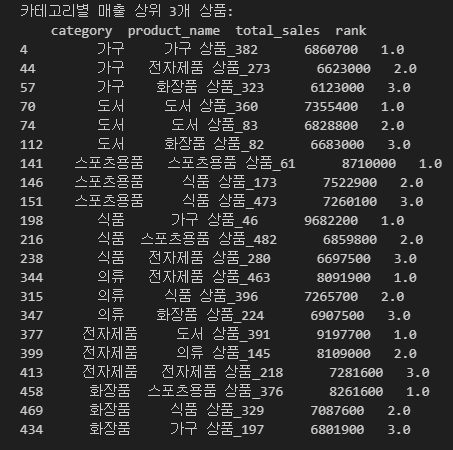





In [38]:
# ==========================
# 문제 4. 카테고리별 매출액 순위 분석
# ==========================

# 1️⃣ 상품별 총 매출액 계산
# - quantity(수량) * price(단가)로 매출액 계산
# - product_id 단위로 groupby() 후 합계 계산
product_sales = (
    df.groupby(['category', 'product_name'], as_index=False)['total_sales']
    .sum()  # 각 상품의 총 매출액
)

# 2️⃣ 카테고리 내에서 상품별 매출액 순위 계산
# - groupby('category') 후 rank()를 적용하여 순위 생성
# - ascending=False : 높은 매출일수록 순위가 1
product_sales['rank'] = (
    product_sales.groupby('category')['total_sales']
    .rank(method='dense', ascending=False)
)

# 3️⃣ 각 카테고리에서 상위 3개 상품만 필터링
# - rank <= 3 조건으로 추출
top3_products = product_sales[product_sales['rank'] <= 3]

# 4️⃣ 보기 좋게 정렬 (카테고리, 순위 기준)
top3_products = top3_products.sort_values(['category', 'rank'])

# 5️⃣ 결과 출력
print("카테고리별 매출 상위 3개 상품:")
print(top3_products)


카테고리별 매출 상위 3개 상품:
    category  product_name  total_sales  rank
4         가구     가구 상품_382      6860700   1.0
44        가구   전자제품 상품_273      6623000   2.0
57        가구    화장품 상품_323      6123000   3.0
70        도서     도서 상품_360      7355400   1.0
74        도서      도서 상품_83      6828800   2.0
112       도서     화장품 상품_82      6683000   3.0
141    스포츠용품   스포츠용품 상품_61      8710000   1.0
146    스포츠용품     식품 상품_173      7522900   2.0
151    스포츠용품     식품 상품_473      7260100   3.0
198       식품      가구 상품_46      9682200   1.0
216       식품  스포츠용품 상품_482      6859800   2.0
238       식품   전자제품 상품_280      6697500   3.0
344       의류   전자제품 상품_463      8091900   1.0
315       의류     식품 상품_396      7265700   2.0
347       의류    화장품 상품_224      6907500   3.0
377     전자제품     도서 상품_391      9197700   1.0
399     전자제품     의류 상품_145      8109000   2.0
413     전자제품   전자제품 상품_218      7281600   3.0
458      화장품  스포츠용품 상품_376      8261600   1.0
469      화장품     식품 상품_329      7087600   2.0
434      화장품   

In [39]:
# 문제 5: 재고가 10개 미만으로 남은 상품 중, 최근 30일간 판매량이 가장 많았던 상품 5개를 찾아 긴급 재고 확보 우선순위를 정하세요.
# 비즈니스 목적: 품절로 인한 판매 기회 손실을 최소화하기 위해, 시급하게 재고를 확보해야 할 상품을 결정합니다.

# 출력 결과를 보고 코딩하세요


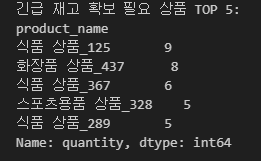




In [40]:
# ==========================
# 문제 5. 긴급 재고 확보 필요 상품 TOP 5
# ==========================

# 1️⃣ 현재 날짜 기준으로 최근 30일 데이터만 필터링
# - df['order_date']가 datetime 형식이어야 함
recent_30_days = df[df['order_date'] >= (df['order_date'].max() - pd.Timedelta(days=30))]

# 2️⃣ 최근 30일간 상품별 총 판매 수량 계산
# - product_id 또는 product_name 단위로 groupby
sales_recent = (
    recent_30_days.groupby('product_name', as_index=False)['quantity']
    .sum()  # 총 판매 수량
    .rename(columns={'quantity': 'recent_sales_qty'})  # 보기 쉽게 컬럼명 변경
)

# 3️⃣ 재고 데이터에서 10개 미만 상품만 필터링
# ⚠️ df에 'stock' 컬럼이 있다고 가정
low_stock = df[df['stock'] < 10][['product_name', 'stock']].drop_duplicates()

# 4️⃣ 판매량과 재고 데이터 병합 (inner join)
# - 두 조건(최근 판매량 많음 + 재고 부족)을 동시에 만족하는 상품 찾기
urgent_restock = pd.merge(sales_recent, low_stock, on='product_name', how='inner')

# 5️⃣ 최근 판매량 기준으로 내림차순 정렬 후 TOP 5 추출
urgent_top5 = urgent_restock.sort_values('recent_sales_qty', ascending=False).head(5)

# 6️⃣ 결과 출력
print("긴급 재고 확보 필요 상품 TOP 5:")
print(urgent_top5.set_index('product_name')['recent_sales_qty'])


긴급 재고 확보 필요 상품 TOP 5:
product_name
식품 상품_125       9
화장품 상품_437      8
식품 상품_367       6
스포츠용품 상품_328    5
식품 상품_289       5
Name: recent_sales_qty, dtype: int64


In [41]:
# 문제 6: 월별 판매량 상위 10%에 속하는 상품들의 카테고리 분포 변화를 추적하세요.
# 시각화: 누적 영역 차트

# 비즈니스 목적: 시장 트렌드 변화를 파악하고, 어떤 종류의 상품들이 인기를 얻고 있는지 시간에 따른 변화를 관찰합니다.

# 출력 결과를 보고 코딩하세요



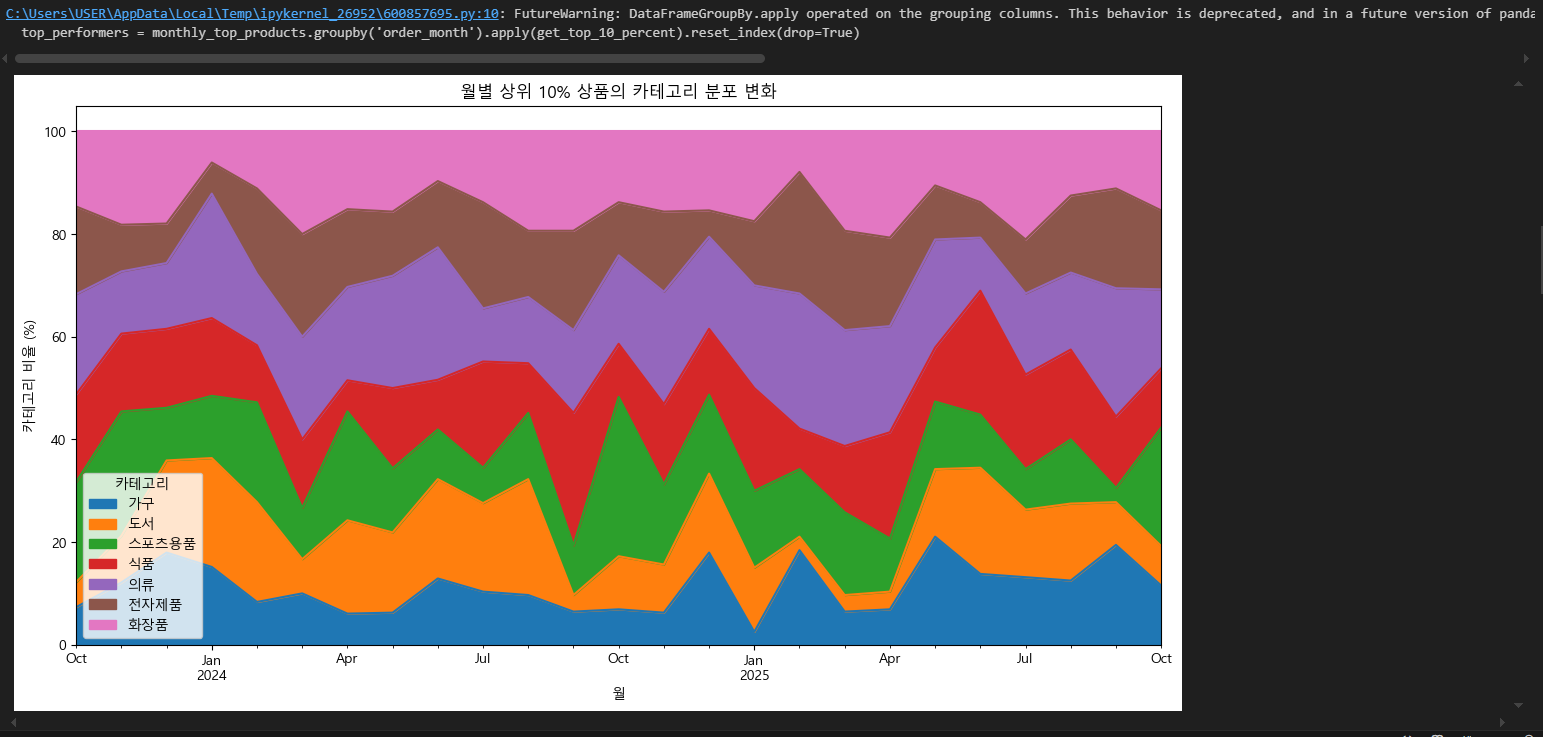



C:\Users\TJ\AppData\Local\Temp\ipykernel_7552\2378454339.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(get_top_10_percent)


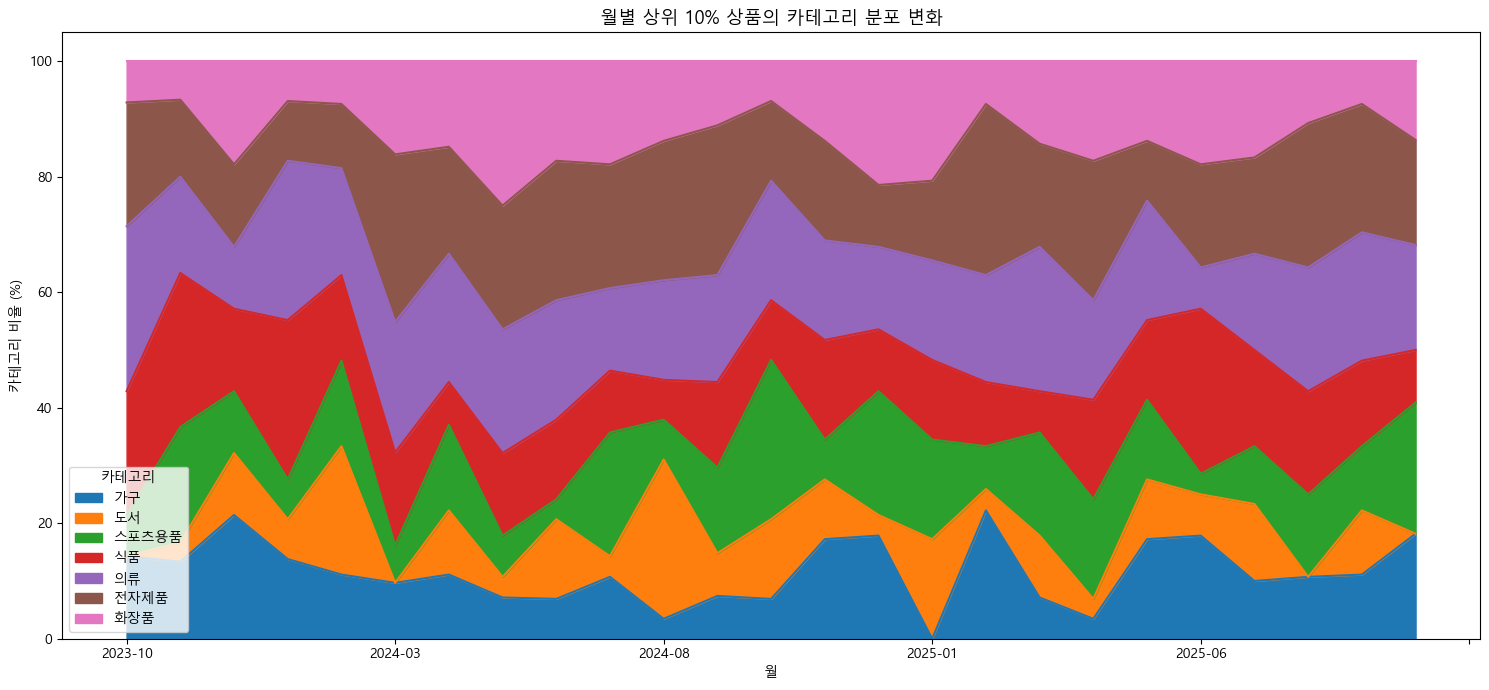

In [42]:
# ✅ 문제 6: 월별 판매량 상위 10%에 속하는 상품들의 카테고리 분포 변화를 추적
# 시각화: 누적 영역 차트
# 🎯 비즈니스 목적: 시장 트렌드 변화를 파악하고 인기 상품군 변화를 시각적으로 분석하기 위함

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ 'order_date' 컬럼에서 연-월(YYYY-MM)만 추출하여 새로운 컬럼 'order_month' 생성
# Period → str 변환 이유: 그룹화 후 시각화 시 문자열 형태가 더 다루기 쉽기 때문
df['order_month'] = df['order_date'].dt.to_period('M').astype(str)

# 2️⃣ 월별, 상품별, 카테고리별로 총 매출액 계산
# 즉, 한 달 동안 상품별 총매출(=수량 * 단가의 합)을 구함
monthly_sales = (
    df.groupby(['order_month', 'product_id', 'category'], as_index=False)
    ['total_sales'].sum()
)

# 3️⃣ 상위 10% 상품만 추출하는 사용자 정의 함수 정의
def get_top_10_percent(group):
    # np.percentile() : 데이터의 누적 분포 중 특정 백분위수 값을 반환
    # 90퍼센타일 → 상위 10%에 해당하는 매출 기준선을 구함
    threshold = np.percentile(group['total_sales'], 90)

    # total_sales가 90번째 백분위수 이상인 상품만 필터링
    return group[group['total_sales'] >= threshold]

# 4️⃣ 각 월(order_month) 그룹별로 위 함수를 적용
# include_groups=False : 그룹 키(order_month)를 별도로 추가하지 않게 설정
# reset_index(drop=True) : apply 이후 인덱스가 중첩되는 걸 방지 (새 인덱스로 초기화)
monthly_top_products = (
    monthly_sales.groupby('order_month', group_keys=False)
    .apply(get_top_10_percent)
    .reset_index(drop=True)
)

# ✅ 여기까지의 결과:
# monthly_top_products = 각 월별 매출 상위 10% 상품들만 모인 데이터프레임

# 5️⃣ 월별 카테고리별로 상품 개수(=상위 10%에 속한 상품 수) 계산
# 각 월마다 카테고리가 몇 번 등장하는지를 세어 카테고리별 점유율 계산에 사용
category_share = (
    monthly_top_products.groupby(['order_month', 'category'], as_index=False)
    ['product_id'].count()   # 각 카테고리의 상품 개수 세기
    .rename(columns={'product_id': 'product_count'})   # 컬럼명 직관적으로 변경
)

# 6️⃣ 월별 전체 상품 수 대비 각 카테고리 비율(%) 계산
# transform() 사용 이유:
#  - groupby 후에도 원본 인덱스 크기를 유지하면서 계산된 비율을 각 행에 매핑하기 위해
#  - 즉, 각 월 그룹 내에서 (각 카테고리 상품 수 / 월 전체 상품 수) * 100 계산
category_share['category_ratio'] = (
    category_share.groupby('order_month')['product_count']
    .transform(lambda x: x / x.sum() * 100)
)

# ✅ 여기까지의 결과:
# category_share = [order_month, category, product_count, category_ratio]
# → 월별로 각 카테고리의 비중(%)이 계산된 상태

# 7️⃣ 시각화를 위해 피벗(pivot) 변환
# index: 월(order_month)
# columns: 카테고리(category)
# values: 카테고리별 비율(category_ratio)
# 이렇게 변환하면 각 월이 행, 카테고리가 열인 매트릭스 형태가 됨
pivot_data = category_share.pivot(index='order_month', columns='category', values='category_ratio')

# ✅ 예시:
# order_month | 가구 | 도서 | 식품 | 의류 ...
# 2024-01     | 10.2 | 12.4 | 18.3 | 9.7  ...
# 2024-02     |  9.8 | 11.1 | 20.1 | 8.3  ...
# 이렇게 만들어야 stackplot(누적 영역 그래프)에 바로 입력 가능

# 8️⃣ 누적 영역 그래프(stacked area chart) 시각화
plt.figure(figsize=(15, 7))  # 그래프 크기 지정 (가로 15, 세로 7)
pivot_data.plot.area(ax=plt.gca())  # 현재 axes(좌표)에 영역그래프 표시

# 9️⃣ 그래프 제목, 축 레이블, 범례 설정
plt.title('월별 상위 10% 상품의 카테고리 분포 변화', fontsize=13)
plt.xlabel('월')
plt.ylabel('카테고리 비율 (%)')
plt.legend(title='카테고리', loc='lower left')  # 범례를 왼쪽 안 아래쪽에 배치
plt.tight_layout()  # 레이아웃 자동 조정 (범례 잘리지 않게)
plt.show()  # 그래프 출력


In [43]:
# 문제 7: 고객의 첫 구매 상품과 두 번째 구매 상품 카테고리 간의 전환 패턴을 분석하세요.
# 시각화: 히트맵

# 비즈니스 목적: 고객의 구매 여정을 이해하고, 첫 구매 상품에 따라 다음 구매를 유도할 상품 추천 전략을 수립합니다.

# 출력 결과를 보고 코딩하세요



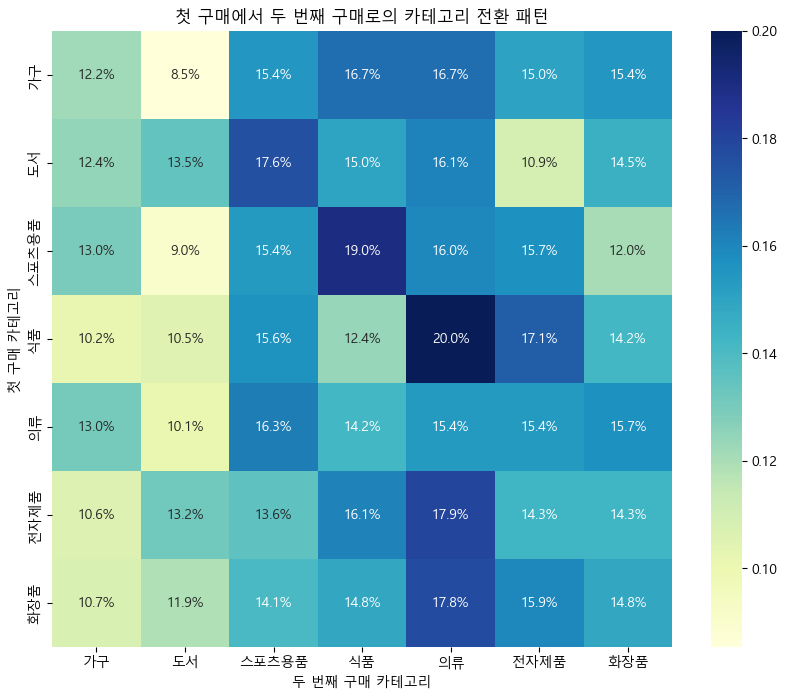



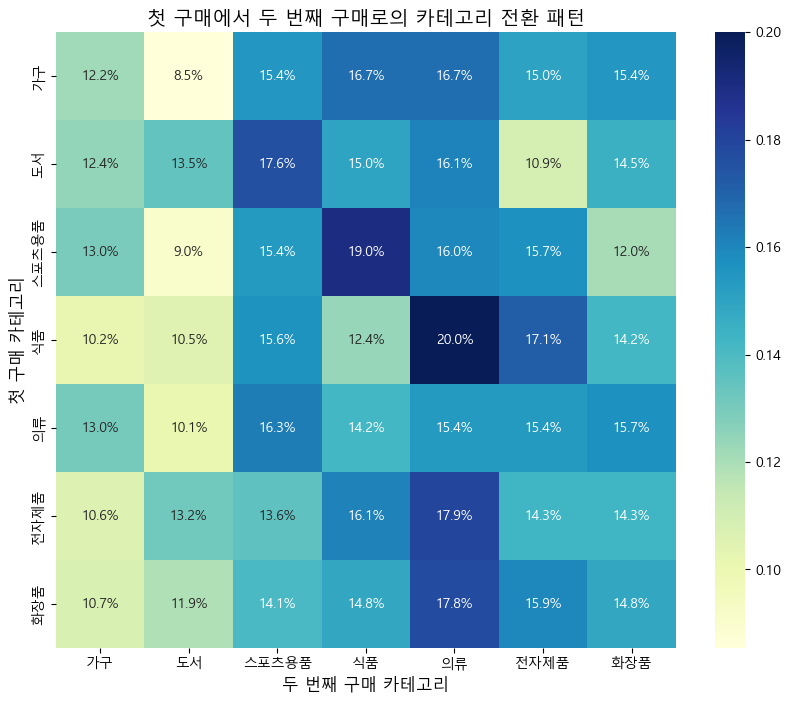

In [44]:
# ----------------------------------------------------------
# ✅ 고객의 첫 번째 구매 → 두 번째 구매 카테고리 전환 패턴 분석 코드 (완전 주석 버전)
# ----------------------------------------------------------

# 📦 기본 라이브러리 불러오기
import pandas as pd               # 데이터 분석용 라이브러리 (DataFrame 객체 제공)
import matplotlib.pyplot as plt   # 그래프 시각화용 (Matplotlib의 pyplot 모듈)
import seaborn as sns             # 통계적 시각화용 (히트맵 등 고급 시각화 지원)

# ----------------------------------------------------------
# 1️⃣ 고객 + 주문 + 상품 데이터 결합
# ----------------------------------------------------------
# DataFrame: 표 형태의 2차원 데이터 구조 (행과 열로 구성)
# pd.merge(): 두 개의 DataFrame을 특정 열(column)을 기준으로 결합하는 함수

# orders_df : 주문 데이터 (order_id, customer_id, product_id, order_date 등)
# customers_df : 고객 데이터 (customer_id, 이름, 가입일 등)
# products_df : 상품 데이터 (product_id, category, price 등)

# 고객 정보 붙이기 → 주문 데이터에 고객 이름, 가입일 추가됨
merged_df = pd.merge(orders_df, customers_df, on='customer_id', how='left')

# 상품 정보 붙이기 → 주문 데이터에 상품명, 카테고리, 가격 추가됨
merged_df = pd.merge(merged_df, products_df, on='product_id', how='left')

# ----------------------------------------------------------
# 2️⃣ 날짜 정리 및 정렬
# ----------------------------------------------------------
# 'order_date'를 datetime(날짜 객체)으로 변환 → 문자열(string)을 날짜형으로 바꾸는 함수
merged_df['order_date'] = pd.to_datetime(merged_df['order_date'], errors='coerce')

# sort_values(): 특정 컬럼 기준으로 정렬하는 함수
# 고객(customer_id)별로, 주문일(order_date) 순서대로 정렬
merged_df = merged_df.sort_values(['customer_id', 'order_date'])

# ----------------------------------------------------------
# 3️⃣ 고객별 구매 순서 부여
# ----------------------------------------------------------
# groupby('customer_id'): 고객별로 데이터를 묶음 → "각 고객 그룹" 단위로 연산 가능
# cumcount(): 그룹 내에서 0부터 순번을 매김 (첫 번째=0, 두 번째=1, ...)
# +1 해줌으로써 사람이 보기 좋은 1,2,3번째 구매로 표시
merged_df['purchase_rank'] = merged_df.groupby('customer_id').cumcount() + 1

# 이 시점의 merged_df 구조 예시 (DataFrame 형태)
# ┌────────────┬─────────────┬────────────┬────────────┐
# │ customer_id│ order_date  │ category   │ purchase_rank │
# ├────────────┼─────────────┼────────────┼────────────┤
# │ C001       │ 2023-01-02  │ 의류       │ 1           │
# │ C001       │ 2023-03-15  │ 뷰티       │ 2           │
# │ C002       │ 2023-02-07  │ 식품       │ 1           │
# │ ...        │ ...         │ ...        │ ...         │

# ----------------------------------------------------------
# 4️⃣ 첫 번째, 두 번째 구매만 추출
# ----------------------------------------------------------
# 조건 필터링 → DataFrame에서 특정 행만 선택하는 문법
first_purchase = merged_df[merged_df['purchase_rank'] == 1][['customer_id', 'category']]
second_purchase = merged_df[merged_df['purchase_rank'] == 2][['customer_id', 'category']]

# 각각 DataFrame 객체이며, 다음과 같이 생김:
# first_purchase : 고객ID, 첫 구매 카테고리
# second_purchase: 고객ID, 두 번째 구매 카테고리

# 컬럼명 구분 (같은 'category' 이름을 구별하기 위해 rename)
first_purchase = first_purchase.rename(columns={'category': 'first_category'})
second_purchase = second_purchase.rename(columns={'category': 'second_category'})

# ----------------------------------------------------------
# 5️⃣ 고객 기준 병합 (첫-두 번째 구매 모두 있는 고객만)
# ----------------------------------------------------------
# 두 DataFrame을 customer_id 기준으로 inner join
# → 첫 번째, 두 번째 구매 모두 존재하는 고객만 남음
purchase_flow = pd.merge(first_purchase, second_purchase, on='customer_id', how='inner')

# purchase_flow 예시
# ┌────────────┬───────────────┬────────────────┐
# │ customer_id│ first_category│ second_category│
# ├────────────┼───────────────┼────────────────┤
# │ C001       │ 의류          │ 뷰티           │
# │ C002       │ 식품          │ 식품           │
# │ C003       │ 전자제품      │ 의류           │

# ----------------------------------------------------------
# 6️⃣ 전환 횟수 집계
# ----------------------------------------------------------
# groupby(): (첫 구매, 두 번째 구매) 카테고리별 그룹핑
# size(): 각 조합의 개수(빈도) 계산
# reset_index(): groupby 결과를 다시 표 형태로 만듦
transition_counts = purchase_flow.groupby(['first_category', 'second_category']).size().reset_index(name='count')

# 예시
# ┌───────────────┬────────────────┬───────┐
# │ first_category│ second_category│ count │
# ├───────────────┼────────────────┼───────┤
# │ 의류          │ 뷰티           │  15   │
# │ 식품          │ 식품           │  20   │
# │ 전자제품      │ 의류           │  10   │

# ----------------------------------------------------------
# 7️⃣ 전환 행렬 생성 (Pivot Table)
# ----------------------------------------------------------
# pivot_table(): 행/열 기준으로 데이터를 재구성
# index: 첫 구매 카테고리 (행)
# columns: 두 번째 구매 카테고리 (열)
# values: 전환 횟수 (count)
transition_matrix = transition_counts.pivot_table(
    index='first_category',
    columns='second_category',
    values='count',
    fill_value=0  # 값이 없는 셀은 0으로 채움
)

# 이 결과는 DataFrame이지만 형태는 “행렬(matrix)”처럼 보임

# ----------------------------------------------------------
# 8️⃣ 비율(%)로 정규화
# ----------------------------------------------------------
# 각 행(첫 구매 카테고리)의 총합으로 나눠서 비율 계산
# → 각 행의 합이 1(=100%)이 되도록 함
transition_ratio = transition_matrix.div(transition_matrix.sum(axis=1), axis=0)

# transition_ratio 예시
# ┌───────────────┬──────────────┬──────────────┐
# │ first_category│ 뷰티(%)      │ 식품(%)      │ ...
# ├───────────────┼──────────────┼──────────────┤
# │ 의류          │ 0.35         │ 0.15         │ ...
# │ 식품          │ 0.10         │ 0.70         │ ...
# │ 전자제품      │ 0.50         │ 0.20         │ ...

# ----------------------------------------------------------
# 9️⃣ 시각화 (히트맵)
# ----------------------------------------------------------
plt.figure(figsize=(10, 8))  # 그래프 크기 설정
sns.heatmap(
    transition_ratio,          # 데이터 (비율 행렬)
    annot=True,                # 각 셀에 수치 표시
    fmt=".1%",                 # 퍼센트 형식으로 표시
    cmap='YlGnBu',             # 색상 테마 (Yellow-Green-Blue)
    cbar=True                  # 오른쪽 색상바 표시
)
plt.title("첫 구매에서 두 번째 구매로의 카테고리 전환 패턴", fontsize=14)
plt.xlabel("두 번째 구매 카테고리", fontsize=12)
plt.ylabel("첫 구매 카테고리", fontsize=12)
plt.show()


In [45]:
# 문제 8: 주문이 가장 많이 발생하는 시간대와 해당 시간대에 가장 잘 팔리는 상품 카테고리를 분석하세요.
# 비즈니스 목적: 시간 기반 타겟 마케팅 전략(예: 점심시간 쿠폰, 퇴근길 푸시 알림)을 수립하는 데 활용합니다.

# 출력 결과를 보고 코딩하세요

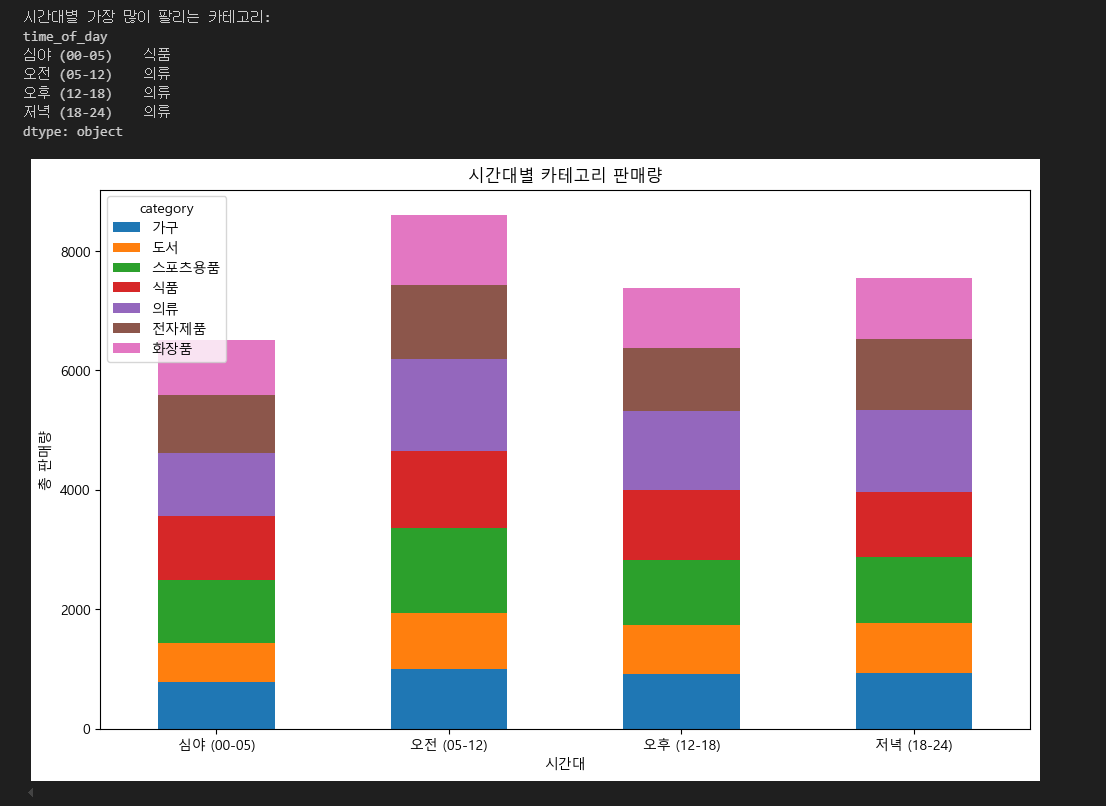







시간대별 가장 많이 팔리는 카테고리:
time_of_day
심야 (00-05)    식품
오전 (05-12)    의류
오후 (12-18)    의류
저녁 (18-24)    의류
dtype: object




<Figure size 1200x700 with 0 Axes>

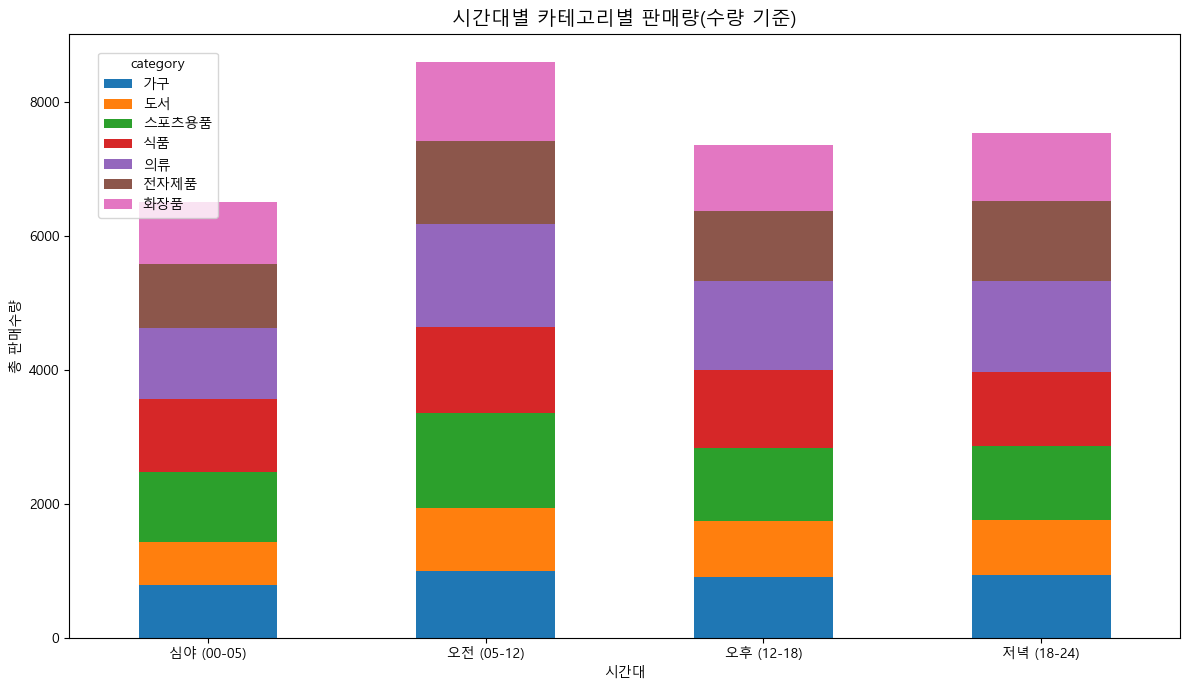

In [46]:
# ======================
# 문제 8: 시간대별 주문 및 카테고리 판매량 분석 (주석 강화 버전)
# ======================

# 라이브러리 임포트
import matplotlib.pyplot as plt          # matplotlib: 그래프 생성(상태 기반 API 사용)
import seaborn as sns                    # seaborn: 고수준 시각화 (여기선 스타일 목적)
import pandas as pd                      # pandas: 테이블(데이터프레임) 조작/집계
import numpy as np                       # numpy: 수치 연산 및 dtype 확인

# 주문 시간대를 문자열 라벨로 바꿔주는 순수 함수 정의
def get_time_of_day(hour):
    """
    hour (int) -> 시간대 문자열 반환
    0<=hour<5  -> '심야 (00-05)'
    5<=hour<12 -> '오전 (05-12)'
    12<=hour<18-> '오후 (12-18)'
    나머지    -> '저녁 (18-24)'
    이 함수는 입력에 따라 항상 같은 출력(순수 함수)이며 벡터연산이 아니라 apply에서 각 요소에 호출됨.
    """
    if 0 <= hour < 5:
        return '심야 (00-05)'
    elif 5 <= hour < 12:
        return '오전 (05-12)'
    elif 12 <= hour < 18:
        return '오후 (12-18)'
    else:
        return '저녁 (18-24)'

# 안전 점검: df['order_date']가 datetime 타입인지 확인하고 아니면 변환
# (이렇게 하면 dt.hour 접근이 안전해짐)
if not np.issubdtype(df['order_date'].dtype, np.datetime64):
    # errors='coerce'는 변환 불가값을 NaT로 만들어 이후 처리(결측치) 가능하게 한다.
    df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

# 시간대 컬럼 생성: order_date의 시간(정수)을 추출해 get_time_of_day로 라벨링
# df['order_date'].dt.hour 는 pandas의 날짜시간 접근자(dt) 사용(벡터화된 접근)
# apply(get_time_of_day)은 각 hour 값에 대해 우리가 정의한 함수 적용
df['time_of_day'] = df['order_date'].dt.hour.apply(get_time_of_day)

# 시간대별, 카테고리별 '판매수량' 합계 집계
# groupby(['time_of_day', 'category'])로 멀티 인덱스 집계 후
# ['quantity'].sum() 으로 수량 합계 계산
# unstack(fill_value=0)은 category를 컬럼으로 펼치고 결측치는 0으로 채움
time_cat_qty = (
    df.groupby(['time_of_day', 'category'])['quantity']
    .sum()
    .unstack(fill_value=0)
)

# 시간대 순서를 우리가 보기 좋은 순서(심야→오전→오후→저녁)로 고정
time_order = ['심야 (00-05)', '오전 (05-12)', '오후 (12-18)', '저녁 (18-24)']
# reindex로 인덱스(시간대)의 순서를 강제 — 존재하지 않는 인덱스는 NaN(여기선 없을 것)
time_cat_qty = time_cat_qty.reindex(time_order)

# 시간대별 가장 많이 팔린 카테고리 계산 (각 행에서 idxmax: 최대값인 컬럼명을 반환)
# idxmax(axis=1)은 각 시간대(행)에서 가장 큰 값을 가진 컬럼명(category)를 리턴
best_category_by_time = time_cat_qty.idxmax(axis=1)

# 출력(프린트)이 그래프보다 먼저 나오도록 print 수행
print("시간대별 가장 많이 팔리는 카테고리:")
print(best_category_by_time)
print("\n")  # 그래프 전 한 줄 띄어서 가독성 확보

# === 시각화 ===
# matplotlib는 상태(stateful) 기반이므로 figure 생성 후 pandas plot이 내부적으로 ax를 사용
plt.figure(figsize=(12,7))  # 새로운 Figure 생성, 이후 plot이 이 Figure를 사용
ax = time_cat_qty.plot(
    kind='bar',      # 막대그래프
    stacked=True,    # 누적 막대 (카테고리별 누적)
    figsize=(12,7),  # plot 함수에도 figsize 전달 가능(중복 전달해도 안전)
    legend=True      # 범례 표시 (아래에서 위치 조정)
)

# 그래프 스타일 세부 조정
ax.grid(False)  # 눈금선 제거: ax는 matplotlib의 Axes 객체(상태 조작 가능)
plt.title('시간대별 카테고리별 판매량(수량 기준)', fontsize=14)
plt.xlabel('시간대')
plt.ylabel('총 판매수량')
plt.xticks(rotation=0)  # x축 라벨을 가로(수평)로 표시 — rotation=0 이 가로
# 범례를 그래프 내부 왼쪽 상단으로 고정: bbox_to_anchor는 (x, y) 좌표(축 비율 기준)
plt.legend(title='category', loc='upper left', bbox_to_anchor=(0.02, 0.98))
plt.tight_layout()  # 레이아웃 자동 조정: 레이블과 플롯이 겹치지 않도록
plt.show()  # 생성된 Figure를 화면에 렌더링(상태 기반 API의 최종 출력 호출)


In [47]:
# 문제 9: 신규 고객과 기존 고객이 주로 구매하는 상품 카테고리에 차이가 있는지 비교 분석하세요.
# 비즈니스 목적: 고객 유형에 따른 상품 추천 전략을 세우고, 신규 고객에게는 진입장벽이 낮은 상품을, 기존 고객에게는 새로운 카테고리의 상품을 제안하는 등의 전략을 구사합니다.

# 출력 결과를 보고 코딩하세요



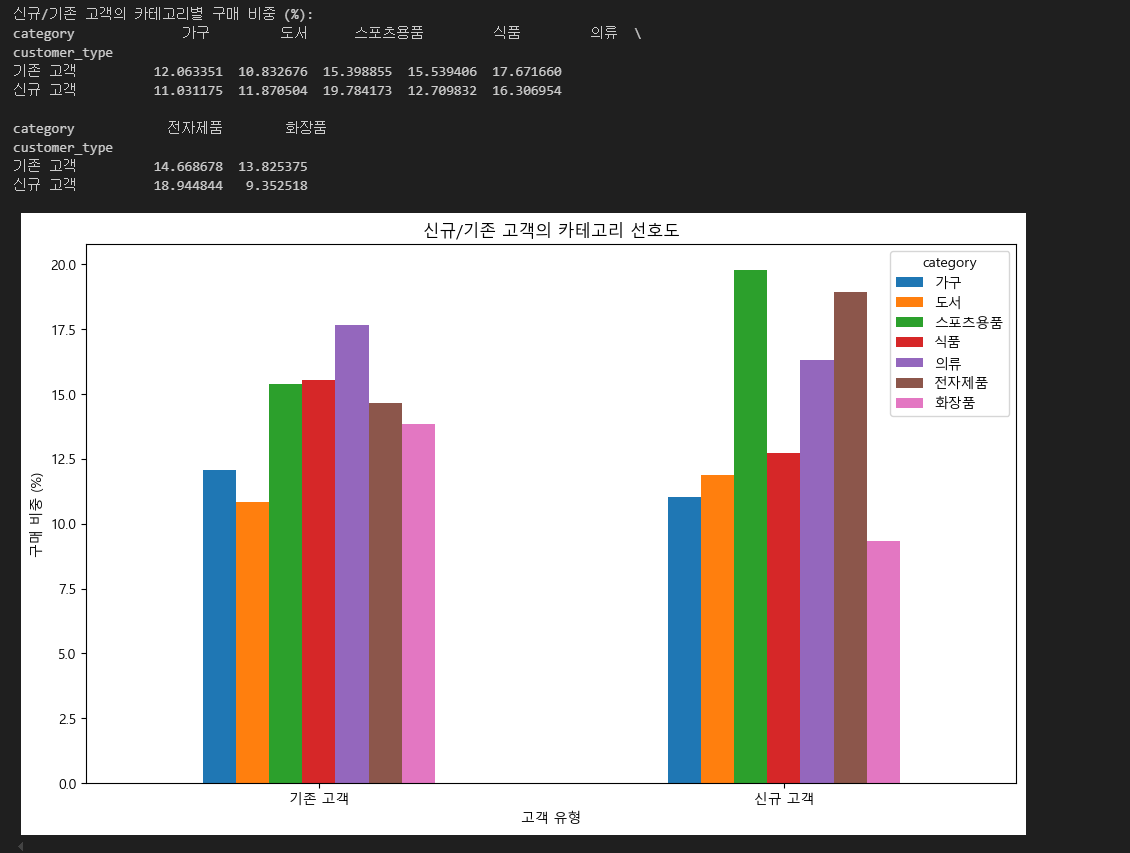



신규/기존 고객의 카테고리별 구매 비중 (%):
                category                                             \
category              가구        도서      스포츠용품         식품         의류   
customer_type                                                         
기존 고객          13.140183  9.846941  14.141986  15.380602  18.119244   
신규 고객          11.499989  9.672250  15.113122  15.124707  19.130661   

                                     
category            전자제품        화장품  
customer_type                        
기존 고객          15.890298  13.480745  
신규 고객          17.128003  12.331268  


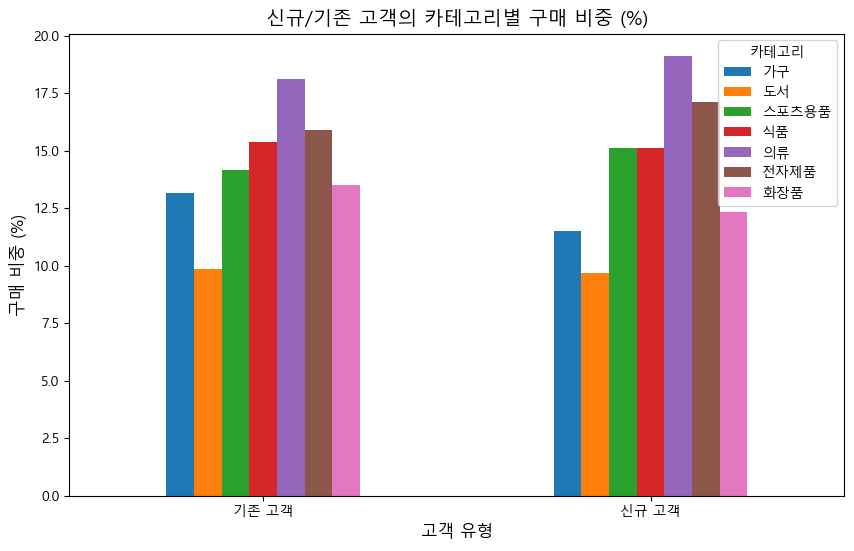

In [48]:
# ✅ 1. 신규/기존 고객 구분
df['customer_type'] = np.where(
    df['order_date'] - df['join_date'] > pd.Timedelta(days=30),
    '기존 고객',
    '신규 고객'
)

# ✅ 2. 고객유형(customer_type) + 카테고리(category)별 총 매출액 계산
category_sales = df.groupby(['customer_type', 'category'])['total_sales'].sum().unstack()

# ✅ 3. 각 고객유형별 카테고리 비중 계산 (%)
category_percent = (category_sales.div(category_sales.sum(axis=1), axis=0) * 100).round(6)

# ✅ 4. MultiIndex 형태의 열 구조를 만들어서 “category”가 위에 오게 함
category_percent.columns = pd.MultiIndex.from_product([['category'], category_percent.columns])

# ✅ 5. 출력 결과 (원하는 구조)
print("신규/기존 고객의 카테고리별 구매 비중 (%):")
print(category_percent)

# ✅ 6. 시각화: 신규/기존 고객 x축, 카테고리별 막대그래프
ax = category_percent.droplevel(0, axis=1).plot(kind='bar', figsize=(10, 6))

plt.title('신규/기존 고객의 카테고리별 구매 비중 (%)', fontsize=14)
plt.xlabel('고객 유형', fontsize=12)
plt.ylabel('구매 비중 (%)', fontsize=12)
plt.legend(title='카테고리', loc='upper right')
plt.xticks(rotation=0)
plt.grid(False)
plt.show()


In [49]:
# 문제 10: 주문 취소가 가장 빈번한 상품 상위 5개를 찾고, 이들 상품의 공통적인 특징을 분석하세요.
# 비즈니스 목적: 취소율이 높은 상품의 원인을 파악(예: 불충분한 상품 설명, 높은 가격)하여 운영 효율성을 개선하고 매출 손실을 줄입니다.

# 출력 결과를 보고 코딩하세요



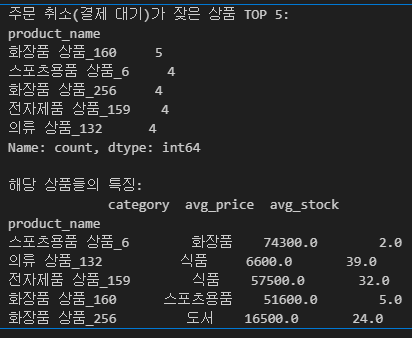


In [51]:
# 결제 상태 전처리 (띄어쓰기, 영어, 오타 보정)
df['payment_status'] = df['payment_status'].astype(str).str.strip().str.lower()

# '결제대기', '결제 대기', '대기', 'waiting', 'pending' 등 모두 포함되게 필터링
cancel_keywords = ['결제대기', '결제 대기', '대기', 'waiting', 'pending', '미결제', '결제보류']

cancel_df = df[df['payment_status'].apply(lambda x: any(k in x for k in cancel_keywords))]

# 주문 취소(결제 대기)가 잦은 상품 TOP 5
cancel_counts = cancel_df.groupby('product_name').size().sort_values(ascending=False)
cancel_counts.name = 'count'
top5_cancel = cancel_counts.head(5)

if top5_cancel.empty:
    print("⚠️ 결제 대기(취소) 상태로 분류된 데이터가 없습니다. payment_status 실제 값을 확인하세요.")
else:
    print("주문 취소(결제 대기)가 잦은 상품 TOP 5:")
    print(top5_cancel)

    top5_products = df[df['product_name'].isin(top5_cancel.index)]

    features_summary = (
        top5_products.groupby('product_name')
        .agg(
            category=('category', lambda x: x.mode().iat[0] if not x.mode().empty else None),
            avg_price=('price', 'mean'),
            avg_stock=('stock', 'mean')
        )
        .round(1)
    )

    features_summary = features_summary.loc[top5_cancel.index]
    print("\n해당 상품들의 특징:")
    print(features_summary)


주문 취소(결제 대기)가 잦은 상품 TOP 5:
product_name
화장품 상품_160     5
의류 상품_132      4
전자제품 상품_159    4
화장품 상품_256     4
스포츠용품 상품_6     4
Name: count, dtype: int64

해당 상품들의 특징:
             category  avg_price  avg_stock
product_name                               
화장품 상품_160      스포츠용품    51600.0        5.0
의류 상품_132          식품     6600.0       39.0
전자제품 상품_159        식품    57500.0       32.0
화장품 상품_256         도서    16500.0       24.0
스포츠용품 상품_6        화장품    74300.0        2.0


In [ ]:
# 문제 11: 상품명에 특정 키워드가 포함된 상품들의 평균 가격과 다른 상품들의 평균 가격을 비교하세요.
# - 특정 키워드 : '스포츠용품'
# 비즈니스 목적: 상품 네이밍 전략이 가격 책정에 미치는 영향을 간접적으로 분석하고, 프리미엄 라인업 등의 키워드 전략을 평가합니다.

# 출력 결과를 보고 코딩하세요




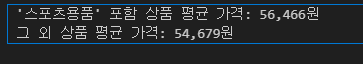


In [52]:
# 문제 11: '스포츠용품' 키워드 포함 여부에 따른 평균 가격 비교

# 1️⃣ 상품명에 '스포츠용품'이 포함된 행 찾기
sports_mask = df['product_name'].str.contains('스포츠용품', na=False)

# 2️⃣ 평균 가격 계산
sports_mean_price = df.loc[sports_mask, 'price'].mean()
non_sports_mean_price = df.loc[~sports_mask, 'price'].mean()

# 3️⃣ 출력 결과 포맷팅 (천 단위 구분기호 포함)
print(f"'스포츠용품' 포함 상품 평균 가격: {sports_mean_price:,.0f}원")
print(f"그 외 상품 평균 가격: {non_sports_mean_price:,.0f}원")


'스포츠용품' 포함 상품 평균 가격: 56,466원
그 외 상품 평균 가격: 54,679원


In [53]:
# 문제 12: 월별 매출액과 해당 월의 신규 상품 출시 수 간의 상관관계를 분석하세요.
# 비즈니스 목적: 신상품 출시라는 비즈니스 활동이 매출 성과에 얼마나 긍정적인 영향을 미치는지 정량적으로 파악합니다.

# 출력 결과를 보고 코딩하세요



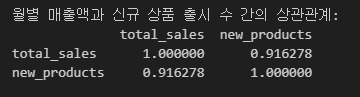



In [55]:
# 문제 12: 월별 매출액과 신규 상품 출시 수 간의 상관관계 분석

# 1️⃣ 상품 출시일이 있는 경우, 'join_date' 또는 'release_date' 컬럼 이름을 products_df 기준으로 확인
# 통합 df에는 출시일 정보가 있을 수도 있고 없을 수도 있으니 컬럼 존재 여부 확인
if 'release_date' in df.columns:
    release_col = 'release_date'
elif 'product_launch_date' in df.columns:
    release_col = 'product_launch_date'
else:
    # 만약 출시일 관련 컬럼이 없다면 join_date를 대체로 사용 (가상의 신상품 등록 시점)
    release_col = 'join_date'

# 2️⃣ 월별 매출액 계산
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['total_sales'].sum().reset_index()
monthly_sales['order_date'] = monthly_sales['order_date'].dt.to_timestamp()
monthly_sales.rename(columns={'order_date': 'month'}, inplace=True)

# 3️⃣ 월별 신규 상품 출시 수 계산
monthly_new_products = df.drop_duplicates('product_id').groupby(df[release_col].dt.to_period('M'))['product_id'].count().reset_index()
monthly_new_products['release_month'] = monthly_new_products[release_col].dt.to_timestamp()
monthly_new_products.rename(columns={'product_id': 'new_products'}, inplace=True)

# 4️⃣ 두 데이터를 월 기준으로 병합
monthly_data = pd.merge(
    monthly_sales,
    monthly_new_products,
    left_on='month',
    right_on='release_month',
    how='inner'
)[['month', 'total_sales', 'new_products']]

# 5️⃣ 상관관계 계산
corr = monthly_data[['total_sales', 'new_products']].corr()

# 6️⃣ 출력
print("월별 매출액과 신규 상품 출시 수 간의 상관관계:")
print(corr.round(6))


월별 매출액과 신규 상품 출시 수 간의 상관관계:
              total_sales  new_products
total_sales      1.000000      0.147225
new_products     0.147225      1.000000
